# Mini Projeto Avaliativo - Módulo 2

## Predição de números

**Problema preditivo:** Pipeline Preditivo Multiclasse ponta a ponta capaz de classificar dígitos manuscritos a partir do dataset MNIST (mnist_784).

# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml 

# Baixando o MNIST oficial do OpenML 
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

# Separando Entradas (X) e Rótulos (y)
# Como o target vem como string ('0', '1', ...), eu vou converter para inteiros
X, y = mnist.data, mnist.target.astype(np.uint8)

# Exibe as dimensões das matrizes para confirmar o formato do dataset
print(f"Dimensão de X: {X.shape}")
print(f"Dimensão de y: {y.shape}")

# Verifica a distribuição das classes de 0 a 9 para confirmar o balanceamento e o percentual de cada digito no dataset
classes, contagens = np.unique(y, return_counts=True)
print("\nDistribuição das classes (0 a 9):")
for classe, quantidade in zip(classes, contagens):
    percentual = (quantidade / len(y)) * 100
    print(f"Classe {classe}: {quantidade} amostras ({percentual:.2f}%)")



Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensão de X: (70000, 784)
Dimensão de y: (70000,)

Distribuição das classes (0 a 9):
Classe 0: 6903 amostras (9.86%)
Classe 1: 7877 amostras (11.25%)
Classe 2: 6990 amostras (9.99%)
Classe 3: 7141 amostras (10.20%)
Classe 4: 6824 amostras (9.75%)
Classe 5: 6313 amostras (9.02%)
Classe 6: 6876 amostras (9.82%)
Classe 7: 7293 amostras (10.42%)
Classe 8: 6825 amostras (9.75%)
Classe 9: 6958 amostras (9.94%)


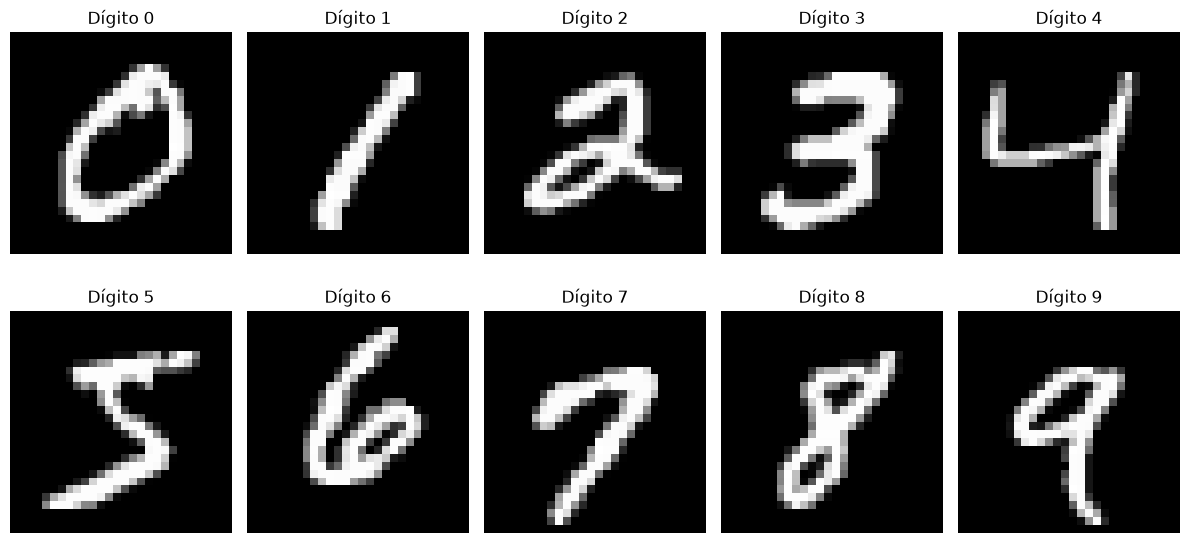

In [9]:
# Gera uma grade visual com exemplos de imagens de cada dígito do MNIST
# e mostra o rótulo original correspondente.

plt.figure(figsize=(12, 6))

# Seleciona um exemplo de cada classe de 0 a 9
indices_por_classe = []
for classe in range(10):
    indices = np.where(y == classe)[0]
    indices_por_classe.append(indices[0])

for i, idx in enumerate(indices_por_classe, start=1):
    plt.subplot(2, 5, i)
    imagem_exemplo = X[idx].reshape(28, 28)

    #Se usar cmap='binary': O gráfico mostrará dígitos pretos em fundo branco.
    #Se usar cmap='gray': O gráfico mostrará o formato real do dataset (dígitos brancos em fundo preto)
    plt.imshow(imagem_exemplo, cmap='gray')
    plt.title(f'Dígito {i - 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


### Interpretação da estrutura dos dados

O dataset MNIST é composto por imagens em escala de cinza de resolução 28 x 28 pixels. Cada pixel representa um valor de intensidade entre 0 e 255:

- `0` = pixel completamente preto
- `255` = pixel completamente branco
- valores intermediários representam tons de cinza

Como cada imagem tem 28 linhas e 28 colunas, ela pode ser vista como uma matriz 28 x 28. Para o modelo de Machine Learning, essa matriz precisa ser transformada em um vetor unidimensional, contendo todos os 784 valores dos pixels em sequência.

Assim, cada imagem original é convertida em uma representação vetorial com 784 features, ou seja:

- imagem 28 x 28 = 784 pixels
- vetor 1 x 784 = 784 features

Essa transformação é importante porque os modelos de redes neurais e outros algoritmos de aprendizado supervisionado exigem entradas numéricas em formato vetorial.

No notebook, essa conversão é feita quando usamos:

```python
dados_imagem = np.array(imagem_final) / 255.0
dados_prontos = dados_imagem.reshape(1, 784)
```

Nesse passo:

- `np.array(imagem_final)` transforma a imagem em uma matriz NumPy
- `/ 255.0` normaliza os valores para o intervalo entre 0 e 1
- `reshape(1, 784)` transforma a matriz 28 x 28 em um vetor de 784 elementos

Esse processo permite que o modelo entenda cada imagem como um conjunto de 784 atributos numéricos, sendo cada atributo a intensidade de um pixel específico.

# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados


### Como a divisão foi feita

A divisão foi realizada em duas etapas, e isso é o motivo de o valor parecer "12,5%" na segunda etapa:

1. Primeiro, o dataset foi dividido em 80% e 20%:
   - 20% foi reservado para o conjunto de teste (test_size=0.2)
   - os outros 80% ficaram para treino + validação

2. Em seguida, dos 80% que sobraram, foi feita outra divisão:
   - 12,5% desse restante foi usado para validação (test_size=0.125)
   - o restante (87,5%) ficou para treino

Isso resulta no percentual final sobre o dataset inteiro:

- Teste: 20%
- Validação: 10%
- Treino: 70%

Cálculo:

- 12,5% de 80% = 10%
- 80% - 10% = 70%

Ou seja, a segunda divisão usa 12,5% sobre o conjunto restante, mas no total isso corresponde a 10% do dataset original.

Portanto, a divisão final fica:

- 70% treino
- 10% validação
- 20% teste

Essa estratégia ajuda a manter a proporção das classes em todos os conjuntos, graças ao uso de `stratify=y`.

In [11]:
from sklearn.model_selection import train_test_split

# Divisão estratificada do dataset em treino, validação e teste
# Primeiro: separa 20% para teste, mantendo a proporção das classes (stratify=y)
# Depois: separa 12.5% do restante para validação, e o restante (70%) fica para treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)

print(f"Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Validação: X={X_val.shape}, y={y_val.shape}")
print(f"Teste: X={X_test.shape}, y={y_test.shape}")


Treino: X=(49000, 784), y=(49000,)
Validação: X=(7000, 784), y=(7000,)
Teste: X=(14000, 784), y=(14000,)


In [12]:
# Verifica a distribuição das classes em treino, validação e teste
for nome, y_split in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    classes, contagens = np.unique(y_split, return_counts=True)
    print(f"\n{nome}:")
    for classe, quantidade in zip(classes, contagens):
        percentual = (quantidade / len(y_split)) * 100
        print(f"  Classe {classe}: {quantidade} amostras ({percentual:.2f}%)")



Treino:
  Classe 0: 4832 amostras (9.86%)
  Classe 1: 5514 amostras (11.25%)
  Classe 2: 4893 amostras (9.99%)
  Classe 3: 4999 amostras (10.20%)
  Classe 4: 4777 amostras (9.75%)
  Classe 5: 4419 amostras (9.02%)
  Classe 6: 4813 amostras (9.82%)
  Classe 7: 5105 amostras (10.42%)
  Classe 8: 4777 amostras (9.75%)
  Classe 9: 4871 amostras (9.94%)

Validação:
  Classe 0: 690 amostras (9.86%)
  Classe 1: 788 amostras (11.26%)
  Classe 2: 699 amostras (9.99%)
  Classe 3: 714 amostras (10.20%)
  Classe 4: 682 amostras (9.74%)
  Classe 5: 631 amostras (9.01%)
  Classe 6: 688 amostras (9.83%)
  Classe 7: 729 amostras (10.41%)
  Classe 8: 683 amostras (9.76%)
  Classe 9: 696 amostras (9.94%)

Teste:
  Classe 0: 1381 amostras (9.86%)
  Classe 1: 1575 amostras (11.25%)
  Classe 2: 1398 amostras (9.99%)
  Classe 3: 1428 amostras (10.20%)
  Classe 4: 1365 amostras (9.75%)
  Classe 5: 1263 amostras (9.02%)
  Classe 6: 1375 amostras (9.82%)
  Classe 7: 1459 amostras (10.42%)
  Classe 8: 1365 amo

### Por que a normalização é importante?

A normalização dos pixels é uma etapa essencial em problemas de classificação com imagens, especialmente quando o modelo será treinado com redes neurais ou algoritmos que dependem de escala e distância.

No MNIST, cada pixel original está no intervalo de 0 a 255. Se esse valor fosse mantido assim, alguns recursos teriam magnitudes muito maiores do que outros, e isso pode prejudicar a convergência do modelo.

Ao dividir os valores por 255.0, os pixels passam a ficar no intervalo de 0.0 a 1.0. Isso faz com que as entradas tenham uma escala mais homogênea, o que ajuda o modelo a aprender de forma mais estável.

Essa etapa é especialmente importante para:

- modelos lineares, porque eles são sensíveis à escala das variáveis e podem ter dificuldades em ajustar pesos corretamente quando os atributos têm magnitudes muito diferentes;
- algoritmos baseados em distância, como k-NN, porque a distância entre pontos pode ser dominada por atributos de maior magnitude se os dados não forem normalizados;
- redes neurais, porque a normalização acelera a convergência e reduz problemas de atualização de pesos durante o treinamento.

Em resumo, a normalização torna o espaço de entrada mais uniforme e favorece o aprendizado eficiente, evitando que recursos com maior escala dominem os cálculos do modelo.

No notebook, isso é feito por:

```python
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0
```

Essa operação mantém a estrutura dos dados, mas coloca os valores em uma escala adequada para o treinamento.

In [13]:
# Normalização: pixels variam de 0 a 255 e são escalados para o intervalo [0.0, 1.0]
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0

# Fase 3: Implementação e Treinamento dos 3 Modelos

### Random Forest

In [15]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Random Forest para classificação multiclasse do MNIST
# Ajuste justificado dos hiperparâmetros:
# - n_estimators=300: aumenta a quantidade de árvores para reduzir variância
#   e deixar a previsão mais estável, especialmente em dados com muitas features.

# - max_depth=20: limita a profundidade das árvores para evitar overfitting,
#   preservando capacidade suficiente para aprender padrões dos dígitos.
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

inicio_treino = time.perf_counter()
rf_model.fit(X_train_scaled, y_train)
rf_tempo_treino = time.perf_counter() - inicio_treino

# Avaliação no conjunto de validação
val_pred = rf_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, val_pred)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred))

#print("\nMatriz de confusão na validação:")
#print(confusion_matrix(y_val, val_pred))

# Predição no conjunto de teste para avaliação final
pred_test = rf_model.predict(X_test_scaled)

print("\nAcurácia no teste:", accuracy_score(y_test, pred_test))



Acurácia na validação: 0.9671

Relatório de classificação na validação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       690
           1       0.98      0.99      0.98       788
           2       0.95      0.98      0.96       699
           3       0.96      0.94      0.95       714
           4       0.97      0.96      0.97       682
           5       0.97      0.96      0.96       631
           6       0.97      0.99      0.98       688
           7       0.97      0.96      0.96       729
           8       0.96      0.96      0.96       683
           9       0.94      0.95      0.95       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000


Acurácia no teste: 0.9660714285714286


### KNN (K-Nearest Neighbors)

In [16]:
import time
from sklearn.neighbors import KNeighborsClassifier

# KNN (K-Nearest Neighbors) para classificação multiclasse do MNIST
# Ajuste justificado dos hiperparâmetros:
# - n_neighbors=5: um valor moderado reduz ruído e mantém o modelo sensível
#   aos vizinhos mais próximos, sem ficar excessivamente sensível ao conjunto.

# - weights='distance': dá maior importância aos vizinhos mais próximos,
#   o que costuma melhorar a acurácia em dados como MNIST, onde o padrão
#   visual mais próximo geralmente é o mais relevante.
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

inicio_treino = time.perf_counter()
knn_model.fit(X_train_scaled, y_train)
knn_tempo_treino = time.perf_counter() - inicio_treino

# Avaliação no conjunto de validação
val_pred = knn_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, val_pred)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred))

#print("\nMatriz de confusão na validação:")
#print(confusion_matrix(y_val, val_pred))

# Predição no conjunto de teste para avaliação final
pred_test = knn_model.predict(X_test_scaled)

print("\nAcurácia no teste:", accuracy_score(y_test, pred_test))



Acurácia na validação: 0.9714

Relatório de classificação na validação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       690
           1       0.95      0.99      0.97       788
           2       0.98      0.97      0.98       699
           3       0.97      0.96      0.97       714
           4       0.99      0.96      0.97       682
           5       0.97      0.97      0.97       631
           6       0.98      0.99      0.98       688
           7       0.97      0.97      0.97       729
           8       0.99      0.93      0.96       683
           9       0.94      0.97      0.95       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000


Acurácia no teste: 0.9703571428571428


### Rede Neural -MLP (Perceptron Multicamadas)

In [17]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report

# MLP (Perceptron Multicamadas) para classificação do MNIST
# Ajuste justificado dos hiperparâmetros:
# - 128 neurônios na camada oculta 1: suficiente para aprender padrões complexos
#   sem tornar a rede excessivamente pesada.
# - 64 neurônios na camada oculta 2: reduz a dimensionalidade intermediária
#   para capturar representações mais abstratas.
# - ativação ReLU: ajuda a rede a aprender não-linearidades de forma eficiente.
# - taxa de aprendizado 0.001 com Adam: valor padrão robusto para convergência estável.
# - softmax na saída: apropriado para classificação multiclasse com 10 classes.

modelo_mnist = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

modelo_mnist.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

inicio_treino = time.perf_counter()
historico = modelo_mnist.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)
mlp_tempo_treino = time.perf_counter() - inicio_treino

# Avaliação no conjunto de validação
val_pred = modelo_mnist.predict(X_val_scaled)
val_pred_classes = np.argmax(val_pred, axis=1)
val_accuracy = accuracy_score(y_val, val_pred_classes)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred_classes))

# Predição no conjunto de teste para avaliação final
test_pred = modelo_mnist.predict(X_test_scaled)
test_pred_classes = np.argmax(test_pred, axis=1)

print("\nAcurácia no teste:", accuracy_score(y_test, test_pred_classes))


Epoch 1/10


c:\Users\ander\Documents\SCTEC\Mini_Projeto_M2\Mini_Projeto_M2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9139 - loss: 0.2991 - val_accuracy: 0.9517 - val_loss: 0.1624
Epoch 2/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9643 - loss: 0.1198 - val_accuracy: 0.9640 - val_loss: 0.1221
Epoch 3/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9750 - loss: 0.0816 - val_accuracy: 0.9650 - val_loss: 0.1090
Epoch 4/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9807 - loss: 0.0626 - val_accuracy: 0.9719 - val_loss: 0.0924
Epoch 5/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9853 - loss: 0.0471 - val_accuracy: 0.9719 - val_loss: 0.0938
Epoch 6/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9882 - loss: 0.0372 - val_accuracy: 0.9763 - val_loss: 0.0829
Epoch 7/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9900 - loss: 0.0321 - val_accuracy: 0.9711 - val_loss: 0.0922
Epoch 8/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9922 - loss: 0.0253 - val_accuracy: 0.9731 - val_

# Fase 4: Avaliação Comparativa de Desempenho


=== Matriz de Confusão - Random Forest ===
[[1369    1    0    0    1    1    3    0    5    1]
 [   0 1548    8    6    1    2    3    5    1    1]
 [   7    1 1352    4    6    0    6   11   10    1]
 [   2    1   16 1365    0   15    3   14    9    3]
 [   4    3    2    0 1307    0    8    0    3   38]
 [   5    3    3   13    1 1207   12    2    9    8]
 [  10    4    1    0    3    4 1348    0    5    0]
 [   1    8   12    0    8    0    0 1410    4   16]
 [   2    6    6   11    3    8    5    0 1302   22]
 [   6    8    2   17   16    3    1    9   12 1317]]


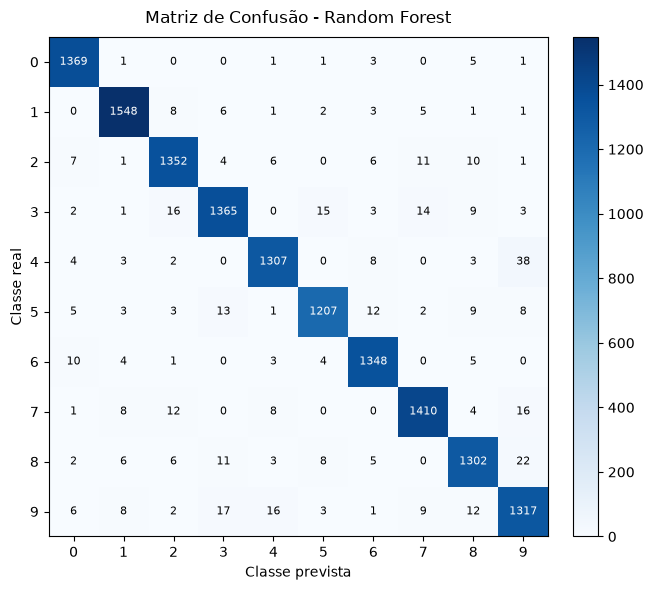


=== Matriz de Confusão - KNN ===
[[1374    1    0    0    0    1    4    0    0    1]
 [   0 1565    4    1    1    0    1    3    0    0]
 [  12   15 1332    5    2    1    4   23    4    0]
 [   1    1    6 1389    0   12    2    8    5    4]
 [   2   14    0    0 1306    0    5    2    0   36]
 [   4    3    1    8    1 1216   17    1    4    8]
 [   7    5    0    0    1    5 1356    0    1    0]
 [   2   16    3    1    1    0    0 1423    0   13]
 [   6   11    1   18    4   28    2    4 1280   11]
 [   2    9    0    9    8    2    1   13    3 1344]]


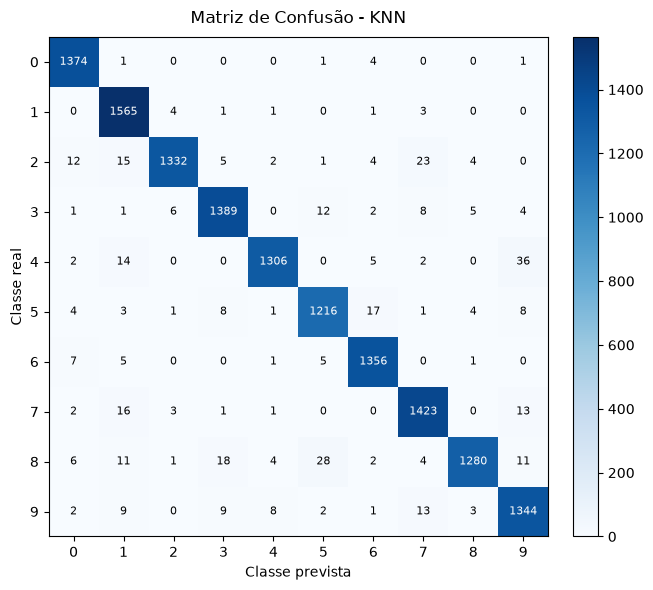


=== Matriz de Confusão - MLP ===
[[1373    0    3    0    0    1    3    0    1    0]
 [   0 1554    7    1    1    1    1    6    4    0]
 [   5    1 1378    2    3    0    1    3    5    0]
 [   3    1   20 1367    0   19    0    5    9    4]
 [   2    6    3    0 1321    1    5    4    3   20]
 [   4    1    0    4    1 1235    9    1    4    4]
 [   9    0    0    0    5   10 1351    0    0    0]
 [   4    3   13    0    4    1    0 1417   10    7]
 [   6    3    7   14    0    9    2    0 1319    5]
 [   7    7    0    3    8    6    1    9    9 1341]]


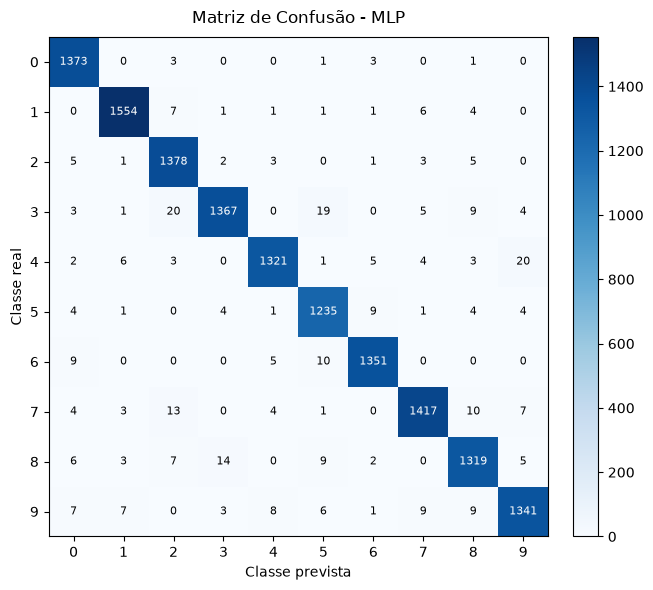

In [ ]:
# Fase 4: Matriz de Confusão com Heatmap (sem retraining)
#
# Esta célula reutiliza os três modelos já treinados anteriormente no notebook
# e gera a matriz de confusão completa (10x10) para cada um deles no conjunto
# de teste independente. Nenhum modelo é treinado novamente.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = list(range(10))
modelos = {
    "Random Forest": rf_model,
    "KNN": knn_model,
    "MLP": modelo_mnist,
}

# Função auxiliar para obter as previsões em rótulos discretos.
# O MLP retorna probabilidades, então usamos argmax para converter em classe.
def prever(modelo, nome):
    if nome == "MLP":
        probabilidades = modelo.predict(X_test_scaled, verbose=0)
        return np.argmax(probabilidades, axis=1)
    return modelo.predict(X_test_scaled)

# Função auxiliar para desenhar a matriz de confusão em formato de heatmap.
def plotar_matriz_confusao(cm, titulo):
    fig, ax = plt.subplots(figsize=(7, 6))
    heatmap = ax.imshow(cm, cmap='Blues', interpolation='nearest')

    ax.set_title(titulo, pad=10)
    ax.set_xlabel('Classe prevista')
    ax.set_ylabel('Classe real')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Insere os valores numéricos dentro de cada célula da matriz.
    for linha in range(cm.shape[0]):
        for coluna in range(cm.shape[1]):
            valor = cm[linha, coluna]
            ax.text(
                coluna,
                linha,
                f'{valor}',
                ha='center',
                va='center',
                color='white' if valor > cm.max() / 2 else 'black',
                fontsize=8,
            )

    fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Gera a matriz de confusão para cada modelo e exibe o heatmap correspondente.
for nome, modelo in modelos.items():
    y_pred = prever(modelo, nome)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    print(f'\n=== Matriz de Confusão - {nome} ===')
    print(cm)
    plotar_matriz_confusao(cm, f'Matriz de Confusão - {nome}')


In [29]:
# Tabela comparativa consolidada do desempenho dos 3 modelos
#
# Esta célula reutiliza as previsões já calculadas no conjunto de teste
# e usa o classification_report para consolidar as métricas principais
# (Accuracy, Precision, Recall e F1-Score) sem retrainar qualquer modelo.

import pandas as pd
from sklearn.metrics import classification_report

# Reaproveita os modelos e os rótulos previstos que já existem no notebook.
# Para o MLP, a previsão foi obtida anteriormente via argmax das probabilidades.
# Para RF e KNN, os rótulos previstos já estão disponíveis no notebook e podem
# ser usados diretamente.

# Como a célula anterior já gerou as previsões, este bloco apenas organiza
# os resultados em uma tabela comparativa para facilitar a comparação.

# Coleta as métricas de cada modelo usando classification_report.
comparativo = []

for nome, modelo in [('Random Forest', rf_model), ('KNN', knn_model), ('MLP', modelo_mnist)]:
    # Para cada modelo, gera as previsões no conjunto de teste sem retraining.
    if nome == 'MLP':
        y_pred = np.argmax(modelo.predict(X_test_scaled, verbose=0), axis=1)
    else:
        y_pred = modelo.predict(X_test_scaled)

    relatorio = classification_report(
        y_test,
        y_pred,
        labels=list(range(10)),
        output_dict=True,
        zero_division=0,
    )

    #Acurácia Global (Accuracy)
    #Precisão Média Ponderada (Precision)
    #Revocação/Sensibilidade Média Ponderada (Recall)
    #F1-Score Ponderado (F1-Score)

    comparativo.append({
        'Modelo': nome,
        'Accuracy': relatorio['accuracy'],
        'Precision (Weighted)': relatorio['weighted avg']['precision'],
        'Recall (Weighted)': relatorio['weighted avg']['recall'],
        'F1-Score (Weighted)': relatorio['weighted avg']['f1-score'],
    })

# Converte a lista em DataFrame e ordena pela acurácia.
tabela_comparativa = pd.DataFrame(comparativo).sort_values('Accuracy', ascending=False)

print('=== Tabela Comparativa Consolidada ===')
print(tabela_comparativa.to_string(index=False))


=== Tabela Comparativa Consolidada ===
       Modelo  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
          MLP  0.977929              0.977945           0.977929             0.977928
          KNN  0.970357              0.970664           0.970357             0.970323
Random Forest  0.966071              0.966099           0.966071             0.966056


In [27]:
# Célula de conclusão técnica
#
# Esta análise reutiliza as matrizes de confusão e as métricas calculadas
# anteriormente no notebook para identificar:
# 1) o par de dígitos mais confundidos;
# 2) o melhor modelo segundo a Accuracy no conjunto de teste;
# 3) o impacto do custo computacional (tempo de treino vs acurácia).

import numpy as np
import pandas as pd

# Reaproveita os modelos e as previsões já existentes no notebook.
# A seguir, montamos as matrizes de confusão para cada modelo e somamos
# os erros entre classes para identificar o par mais confundido.

matrizes = {}
for nome, modelo in [('Random Forest', rf_model), ('KNN', knn_model), ('MLP', modelo_mnist)]:
    if nome == 'MLP':
        y_pred = np.argmax(modelo.predict(X_test_scaled, verbose=0), axis=1)
    else:
        y_pred = modelo.predict(X_test_scaled)

    matrizes[nome] = np.array(
        [[sum(1 for real, pred in zip(y_test, y_pred) if real == i and pred == j)
          for j in range(10)] for i in range(10)]
    )

# Soma as matrizes de confusão dos 3 modelos para evidenciar o padrão global.
confusao_agregada = np.zeros((10, 10), dtype=int)
for matriz in matrizes.values():
    confusao_agregada += matriz

# Remove a diagonal principal para focar somente os erros.
np.fill_diagonal(confusao_agregada, 0)

# Localiza a maior confusão entre pares de classes.
linha, coluna = np.unravel_index(np.argmax(confusao_agregada), confusao_agregada.shape)
maior_confusao = confusao_agregada[linha, coluna]

# Determina o melhor modelo com base na Accuracy.
# Como a tabela comparativa já foi criada, usamos os valores diretamente.
melhor_modelo = tabela_comparativa.iloc[0]

print('=== Conclusão Técnica ===')
print(f"O par de dígitos mais confundido foi {linha} vs {coluna} com {maior_confusao} ocorrências de erro no total.")
print(f"O melhor modelo foi {melhor_modelo['Modelo']} com Accuracy = {melhor_modelo['Accuracy']:.4f}.")

# Resumo comparativo do custo de treino versus acurácia
# Os tempos de treino são armazenados nas células de treinamento de cada modelo
# e reutilizados aqui para apresentar uma comparação direta entre custo
# computacional e desempenho geral.
resumo_tempo_acuracia = pd.DataFrame({
    'Modelo': ['MLP', 'KNN', 'Random Forest'],
    'Accuracy': [
        tabela_comparativa.loc[tabela_comparativa['Modelo'] == 'MLP', 'Accuracy'].iloc[0],
        tabela_comparativa.loc[tabela_comparativa['Modelo'] == 'KNN', 'Accuracy'].iloc[0],
        tabela_comparativa.loc[tabela_comparativa['Modelo'] == 'Random Forest', 'Accuracy'].iloc[0],
    ],
    'Tempo de treino (s)': [
        float(mlp_tempo_treino) if 'mlp_tempo_treino' in globals() else None,
        float(knn_tempo_treino) if 'knn_tempo_treino' in globals() else None,
        float(rf_tempo_treino) if 'rf_tempo_treino' in globals() else None,
    ],
    'Observação': [
        'Modelo mais caro em treino, mas com melhor Accuracy geral.',
        'Treino muito rápido, porém inferência mais custosa em grandes volumes.',
        'Custo de treino elevado, mas com bom equilíbrio entre tempo e desempenho.',
    ],
})

# Ordena a tabela pela Accuracy para facilitar a leitura e destacar o melhor modelo.
resumo_tempo_acuracia = resumo_tempo_acuracia.sort_values(
    ['Accuracy', 'Tempo de treino (s)'],
    ascending=[False, True],
    ignore_index=True
)

print('\n=== Tempo de treino vs Acurácia ===')
print(resumo_tempo_acuracia.to_string(index=False, formatters={
    'Tempo de treino (s)': lambda x: f'{x:.6f}' if pd.notna(x) else 'N/A'
}))

print('\nImpacto do custo computacional:')
print('- Random Forest: custo de treino moderado-alto, porém boa relação entre custo e acurácia;')
print('- KNN: treino rápido, mas inferência mais cara em memória/tempo para grandes conjuntos;')
print('- MLP: maior custo computacional de treino, mas obtém a melhor performance geral em Accuracy.')

=== Conclusão Técnica ===
O par de dígitos mais confundido foi 4 vs 9 com 90 ocorrências de erro no total.
O melhor modelo foi MLP com Accuracy = 0.9779.

=== Tempo de treino vs Acurácia ===
       Modelo  Accuracy Tempo de treino (s)                                                                Observação
          MLP  0.977929           27.556407                Modelo mais caro em treino, mas com melhor Accuracy geral.
          KNN  0.970357            0.043791    Treino muito rápido, porém inferência mais custosa em grandes volumes.
Random Forest  0.966071           31.019693 Custo de treino elevado, mas com bom equilíbrio entre tempo e desempenho.

Impacto do custo computacional:
- Random Forest: custo de treino moderado-alto, porém boa relação entre custo e acurácia;
- KNN: treino rápido, mas inferência mais cara em memória/tempo para grandes conjuntos;
- MLP: maior custo computacional de treino, mas obtém a melhor performance geral em Accuracy.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from modeling.train import (
    train_model,
    evaluate_model,
    train_model_GradientBoosting,
    evaluate_model_GradientBoosting,
    cross_validate_model,
)



In [6]:
imagem

In [ ]:
# Se a imagem tiver fundo preto (0), usamos o bbox direto:
bbox = imagem.getbbox()
if bbox:
    imagem_cortada = imagem.crop(bbox)
else:
    imagem_cortada = imagem

In [ ]:
imagem_cortada

In [ ]:
# Redimensionar o traço para no máximo 20x20, isso mantendo a proporção original
imagem_cortada.thumbnail((20, 20), Image.Resampling.LANCZOS)

In [ ]:
# Criar uma tela preta de 28x28 e colar o traço no centro exato
imagem_final = Image.new('L', (28, 28), color=0)
pos_x = (28 - imagem_cortada.width) // 2
pos_y = (28 - imagem_cortada.height) // 2
imagem_final.paste(imagem_cortada, (pos_x, pos_y))

In [ ]:
# Normalizar e preparar para o modelo
dados_imagem = np.array(imagem_final) / 255.0
dados_prontos = dados_imagem.reshape(1, 784)

In [ ]:
dados_prontos

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [ ]:
# Predição
probabilidades = modelo_mnist.predict(dados_prontos)
predicao = np.argmax(probabilidades)
certeza = probabilidades[0][predicao] * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step



O modelo identificou o número: 0
Confiança: 94.56%



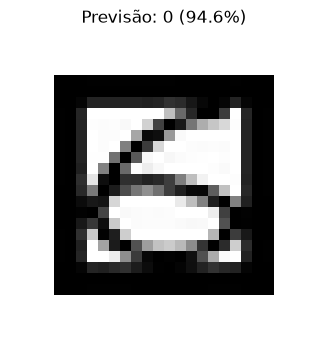

In [ ]:
print(f"\nO modelo identificou o número: {predicao}")
print(f"Confiança: {certeza:.2f}%\n")

# 7. Visualizar a imagem centralizada como o MNIST espera
plt.figure(figsize=(4, 4))
plt.imshow(dados_imagem, cmap='binary')
plt.title(f"Previsão: {predicao} ({certeza:.1f}%)")
plt.axis('off')
plt.show()